In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
ml_df = pd.read_csv("wfp_uganda_food_prices_ml_ready.csv")

ml_df.head()

,date,year,month,quarter,admin1,admin2,market,market_id,latitude,longitude,...,commodity,commodity_id,unit,price,previous_price,price_change,price_pct_change,price_3_month_avg,price_6_month_avg,next_month_price
0,2011-09-15,2011,9,3,Kyankwanzi,Kiboga,Kiboga,257,0.92,31.77,...,Beans,50,KG,1500.0,1667.0,-167.0,-0.100180,1555.666667,1794.500000,1900.0
1,2011-10-15,2011,10,4,Kyankwanzi,Kiboga,Kiboga,257,0.92,31.77,...,Beans,50,KG,1900.0,1500.0,400.0,0.266667,1689.000000,1786.166667,1632.0
2,2011-11-15,2011,11,4,Kyankwanzi,Kiboga,Kiboga,257,0.92,31.77,...,Beans,50,KG,1632.0,1900.0,-268.0,-0.141053,1677.333333,1699.833333,1425.0
3,2012-01-15,2012,1,1,Kyankwanzi,Kiboga,Kiboga,257,0.92,31.77,...,Beans,50,KG,1425.0,1632.0,-207.0,-0.126838,1652.333333,1604.000000,1450.0
4,2012-02-15,2012,2,1,Kyankwanzi,Kiboga,Kiboga,257,0.92,31.77,...,Beans,50,KG,1450.0,1425.0,25.0,0.017544,1502.333333,1595.666667,1609.0


In [4]:
ml_df.shape

(20872, 21)

In [5]:
ml_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20872 entries, 0 to 20871
Data columns (total 21 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   date               20872 non-null  object 
 1   year               20872 non-null  int64  
 2   month              20872 non-null  int64  
 3   quarter            20872 non-null  int64  
 4   admin1             20872 non-null  object 
 5   admin2             20872 non-null  object 
 6   market             20872 non-null  object 
 7   market_id          20872 non-null  int64  
 8   latitude           20872 non-null  float64
 9   longitude          20872 non-null  float64
 10  category           20872 non-null  object 
 11  commodity          20872 non-null  object 
 12  commodity_id       20872 non-null  int64  
 13  unit               20872 non-null  object 
 14  price              20872 non-null  float64
 15  previous_price     20872 non-null  float64
 16  price_change       208

In [6]:
# convert date to datetime type again since its showing the type as object
ml_df["date"] = pd.to_datetime(ml_df["date"])

ml_df.dtypes

,0
date,datetime64[ns]
year,int64
month,int64
quarter,int64
admin1,object
admin2,object
market,object
market_id,int64
latitude,float64
longitude,float64


In [7]:
ml_df.describe()

,date,year,month,quarter,market_id,latitude,longitude,commodity_id,price,previous_price,price_change,price_pct_change,price_3_month_avg,price_6_month_avg,next_month_price
count,20872,20872.000000,20872.000000,20872.00000,20872.000000,20872.000000,20872.000000,20872.000000,20872.000000,20872.000000,20872.000000,20872.000000,20872.000000,20872.000000,20872.000000
mean,2022-01-14 04:47:21.088539904,2021.537610,6.549300,2.51811,3779.481075,1.592159,32.301729,160.445765,3441.605277,3428.384796,13.220482,0.049365,3428.826130,3410.069793,3453.639590
min,2008-12-15 00:00:00,2008.000000,1.000000,1.00000,257.000000,-0.940000,30.070000,50.000000,2.000000,2.000000,-44869.000000,-0.998363,285.133333,308.900000,2.000000
25%,2021-03-15 00:00:00,2021.000000,4.000000,2.00000,263.000000,0.360000,31.090000,67.000000,1457.750000,1447.000000,-110.000000,-0.050000,1456.666667,1450.000000,1467.000000
50%,2023-04-15 00:00:00,2023.000000,7.000000,3.00000,6148.000000,1.690000,32.310000,74.000000,2044.500000,2020.500000,0.000000,0.000000,2074.333333,2069.635833,2067.000000
75%,2024-09-15 00:00:00,2024.000000,10.000000,4.00000,6410.000000,3.000000,33.470000,96.000000,3730.750000,3712.250000,125.000000,0.063019,3682.833333,3637.583333,3750.000000
max,2026-05-15 00:00:00,2026.000000,12.000000,4.00000,7957.000000,3.570000,34.830000,900.000000,66608.000000,66608.000000,25907.000000,542.000000,43227.000000,33750.166667,66608.000000
std,NaN,3.849129,3.428925,1.11069,2864.774226,1.404049,1.317002,222.995054,4119.322213,4105.269851,1226.391193,3.758770,4039.309957,3991.898200,4134.444675


In [8]:
ml_df.isna().sum()

,0
date,0
year,0
month,0
quarter,0
admin1,0
admin2,0
market,0
market_id,0
latitude,0
longitude,0


The cleaned dataset contains retail food price records for Ugandan markets. The dataset includes location variables, commodity variables, time variables, historical price features, and the target variable `next_month_price`.

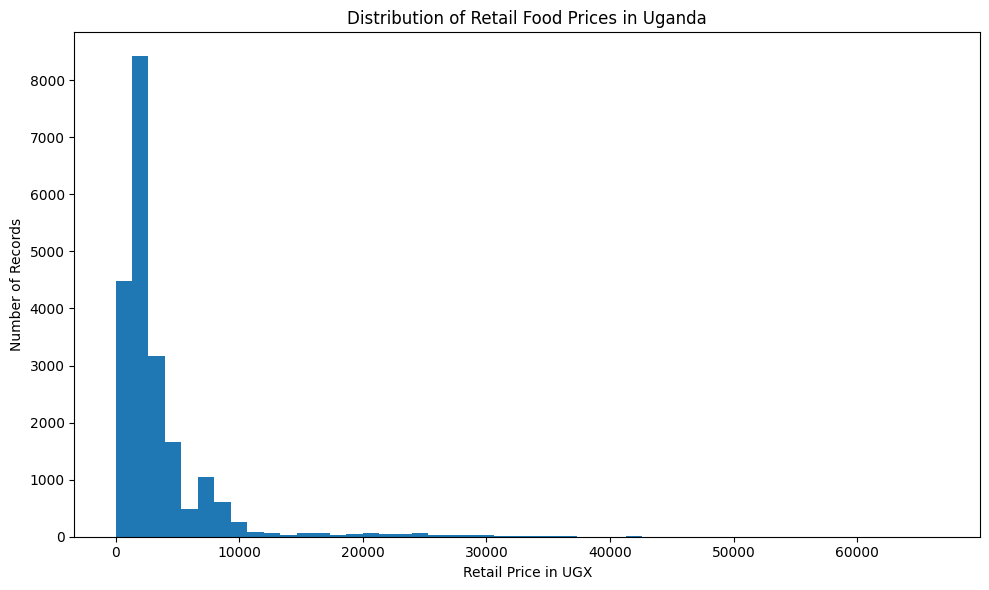

In [16]:
# univariate visualization
plt.figure(figsize=(10,6))
plt.hist(ml_df["price"], bins=50)
plt.title("Distribution of Retail Food Prices in Uganda")
plt.xlabel("Retail Price in UGX")
plt.ylabel("Number of Records")
plt.tight_layout()
plt.savefig("figures/Distribution_of_Retail_Food_Prices_in_Uganda.png", dpi=300)
plt.show()


The price distribution shows how retail food prices are spread across the dataset. Most prices are concentrated at lower values, while a smaller number of records have very high prices. This suggests that the dataset may contain price outliers or commodities with naturally higher prices.

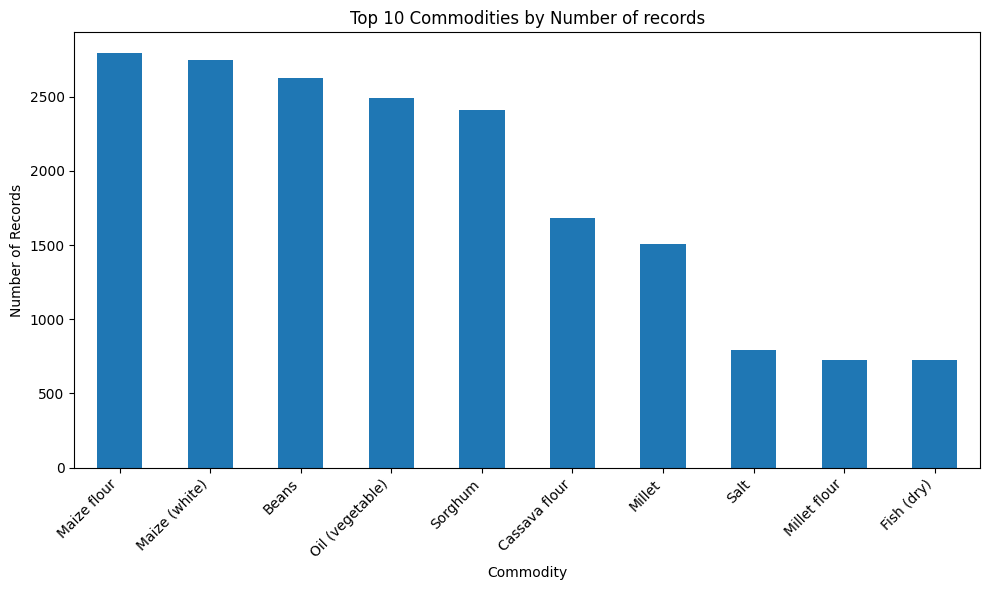

In [17]:
# Top ten commodities
top_commodities = ml_df["commodity"].value_counts().head(10)

plt.figure(figsize=(10,6))
top_commodities.plot(kind="bar")
plt.title("Top 10 Commodities by Number of records")
plt.xlabel("Commodity")
plt.ylabel("Number of Records")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig("figures/Top_10_categories_by_Number_of_records.png", dpi=300)
plt.show()

The chart shows the commodities with the highest number of records in the dataset. Commodities with more records provide more information for the machine learning model and are likely to contribute strongly to model learning.

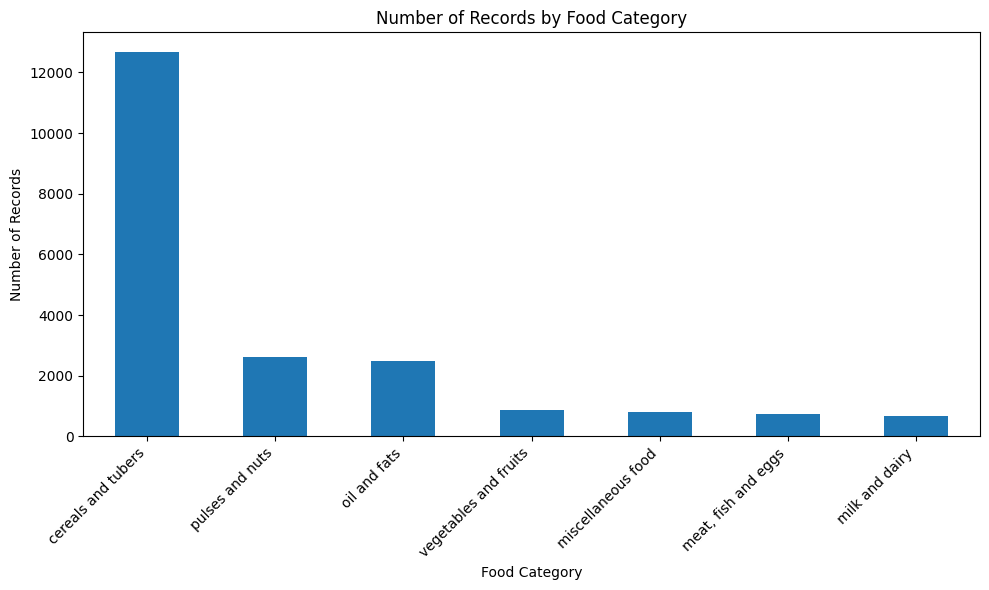

In [18]:
# Records by food category
category_counts = ml_df["category"].value_counts()

plt.figure(figsize=(10, 6))
category_counts.plot(kind="bar")
plt.title("Number of Records by Food Category")
plt.xlabel("Food Category")
plt.ylabel("Number of Records")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig("figures/number_of_records_by_food_category.png", dpi=300)
plt.show()

The chart shows the distribution of records across food categories. Some categories have more observations than others, meaning the dataset is not evenly distributed across all food groups.


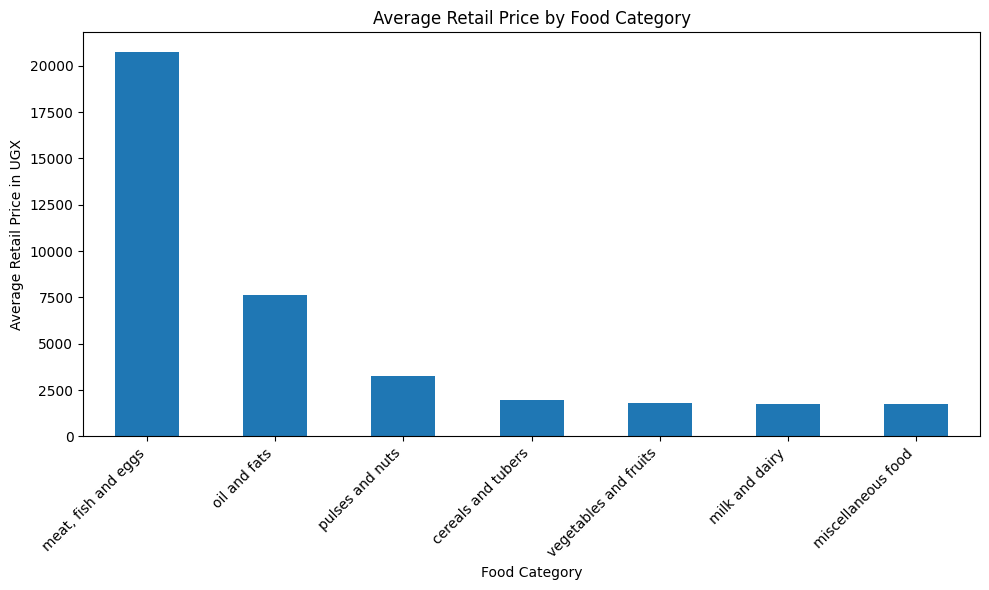

In [19]:
# Multivariant Visualization

# Average price by category

avg_price_category = ml_df.groupby("category")["price"].mean().sort_values(ascending=False)


plt.figure(figsize=(10, 6))
avg_price_category.plot(kind="bar")
plt.title("Average Retail Price by Food Category")
plt.xlabel("Food Category")
plt.ylabel("Average Retail Price in UGX")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig("figures/Average_retail_price_by_food_category.png", dpi=300)
plt.show()

The chart compares average retail prices across food categories. Categories with higher average prices may contain commodities that are naturally more expensive per unit, while lower categories may contain staple foods with lower unit prices.

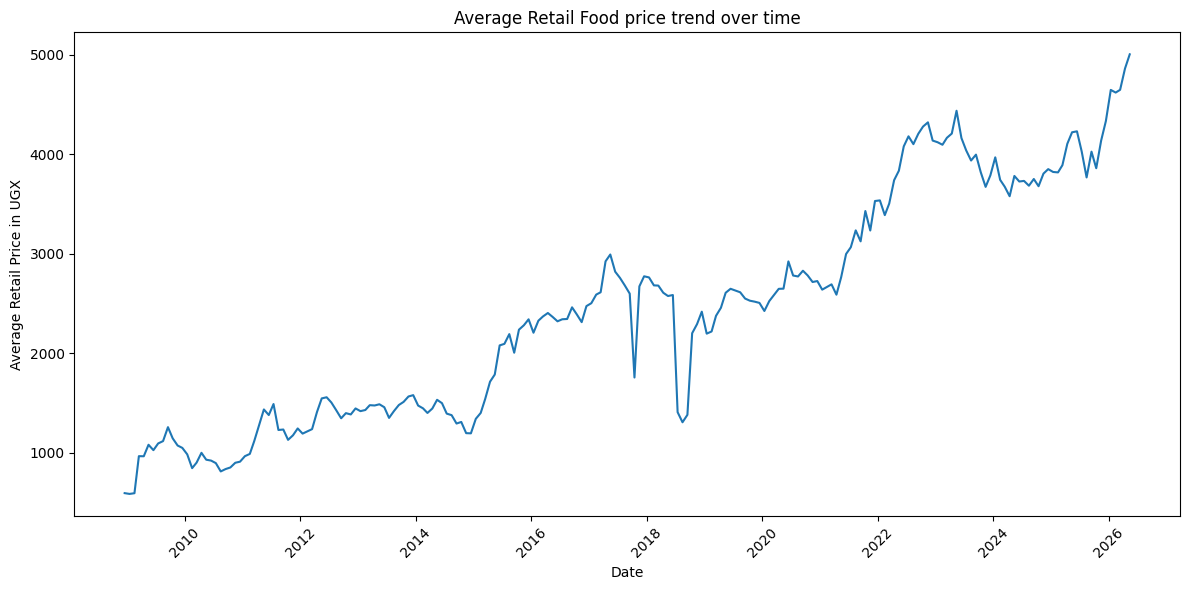

In [20]:
# Average Price over time

monthly_avg_price = ml_df.groupby("date")["price"].mean().reset_index()

plt.figure(figsize=(12, 6))
plt.plot(monthly_avg_price["date"], monthly_avg_price["price"])
plt.title("Average Retail Food price trend over time")
plt.xlabel("Date")
plt.ylabel("Average Retail Price in UGX")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("figures/Average_retail_price.png", dpi=300)
plt.show()


The line chart shows the overall trend of average retail food prices over time. Increases or decreases in the trend may reflect changes in market conditions, inflation, supply shortages, seasonal patterns, or economic shocks.

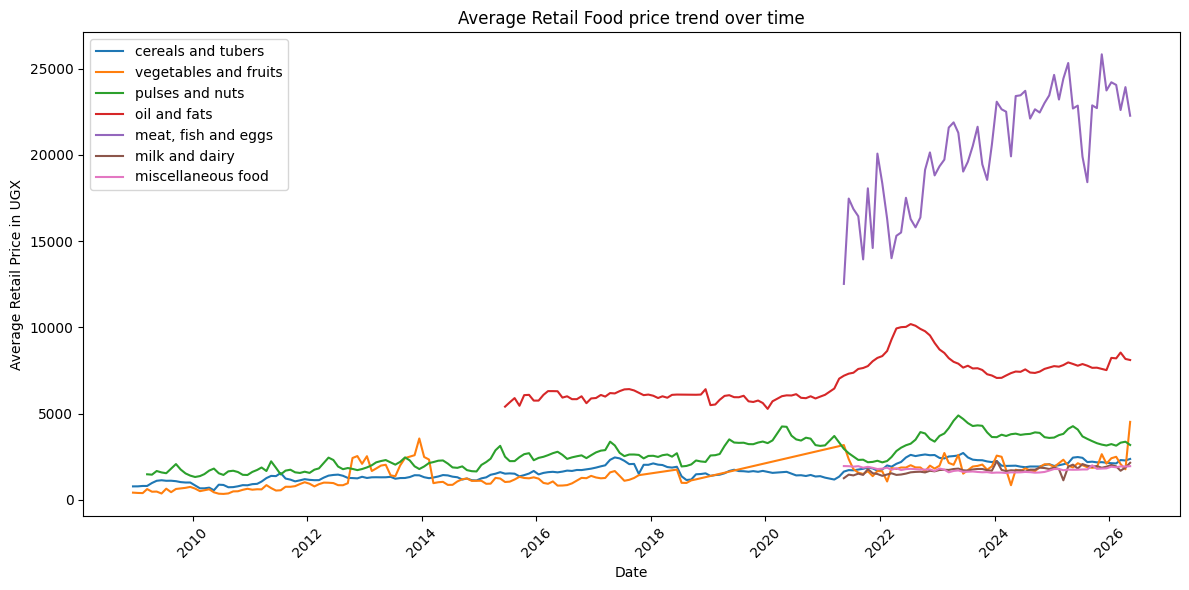

In [21]:
# Multi variant-price by category overtime
category_time_price = ml_df.groupby(["date","category"])["price"].mean().reset_index()

plt.figure(figsize=(12, 6))

for category in category_time_price["category"].unique():
    category_data = category_time_price[category_time_price["category"] == category]
    plt.plot(category_data["date"], category_data["price"], label = category)


plt.title("Average Retail Food price trend over time")
plt.xlabel("Date")
plt.ylabel("Average Retail Price in UGX")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("figures/Average_Retail_price.png", dpi=300)
plt.legend()

This chart shows how average retail prices changed over time for different food categories. Comparing categories helps identify which food groups experienced stronger price increases or greater volatility.

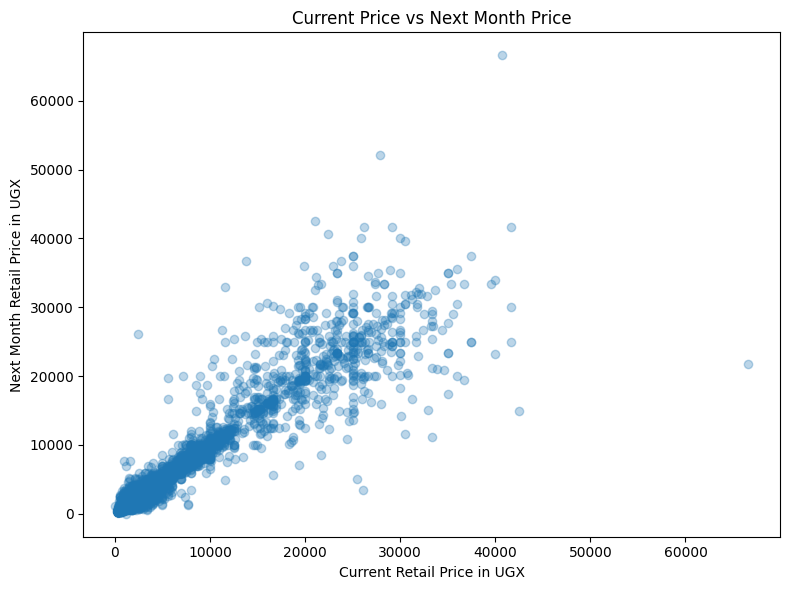

In [22]:
# Multi variant: Current Price vs Next Months Price
plt.figure(figsize=(8, 6))
plt.scatter(ml_df["price"], ml_df["next_month_price"], alpha=0.3)
plt.title("Current Price vs Next Month Price")
plt.xlabel("Current Retail Price in UGX")
plt.ylabel("Next Month Retail Price in UGX")
plt.tight_layout()
plt.savefig("figures/current_price_vs_next_month_price.png", dpi=300)
plt.show()

The scatter plot shows the relationship between the current retail price and the next month retail price. A clear positive pattern would suggest that current price is a useful predictor of next month price.

The scatter plot shows a strong positive relationship between current retail price and next month retail price. This suggests that commodities with high current prices are likely to have high prices in the following month, while commodities with low current prices are likely to remain relatively low.

This supports the use of regression modelling because the target variable `next_month_price` appears to be related to the current and historical price features.

In [23]:
# correlation check for numeric features

numeric_cols = [
    "price",
    "previous_price",
    "price_change",
    "price_pct_change",
    "price_3_month_avg",
    "price_6_month_avg",
    "next_month_price"
]

correlation_matrix = ml_df[numeric_cols].corr()

correlation_matrix


,price,previous_price,price_change,price_pct_change,price_3_month_avg,price_6_month_avg,next_month_price
price,1.000000,0.955537,0.160297,0.000987,0.982370,0.973514,0.954112
previous_price,0.955537,1.000000,-0.137890,-0.010112,0.986614,0.977935,0.942953
price_change,0.160297,-0.137890,1.000000,0.037163,-0.002951,-0.003642,0.048287
price_pct_change,0.000987,-0.010112,0.037163,1.000000,-0.004945,-0.005013,-0.002295
price_3_month_avg,0.982370,0.986614,-0.002951,-0.004945,1.000000,0.993126,0.961685
price_6_month_avg,0.973514,0.977935,-0.003642,-0.005013,0.993126,1.000000,0.960109
next_month_price,0.954112,0.942953,0.048287,-0.002295,0.961685,0.960109,1.000000


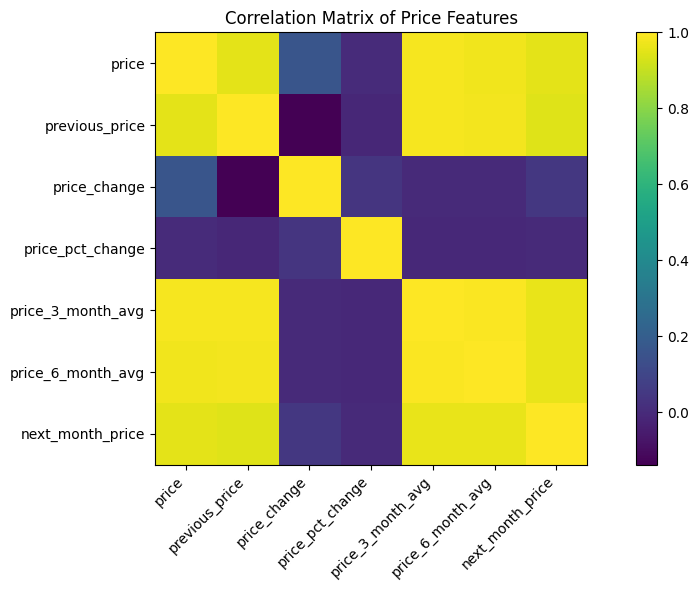

In [24]:
# Visualize using matplot lib
plt.figure(figsize=(10, 6))
plt.imshow(correlation_matrix)
plt.colorbar()
plt.xticks(range(len(numeric_cols)), numeric_cols, rotation=45, ha="right")
plt.yticks(range(len(numeric_cols)), numeric_cols)
plt.title("Correlation Matrix of Price Features")
plt.tight_layout()
plt.savefig("figures/correlation.png", dpi=300)
plt.show()

The correlation matrix shows the strength of relationships between numerical price features. Features such as current price, previous price, and moving averages are expected to have a strong relationship with next month price, making them useful for regression modelling.

The correlation matrix shows that current price, previous price, 3-month moving average price, and 6-month moving average price have a strong positive relationship with the target variable `next_month_price`.

This means that historical price information is useful for predicting future food prices. The strongest predictors appear to be the current price and moving average price features.

The variables `price_change` and `price_pct_change` show weaker relationships with `next_month_price`, meaning that short-term price changes alone may not be enough to predict future prices.

In [25]:
# check average price commodities
avg_price_commodity = ml_df.groupby("commodity")["price"].mean().sort_values(ascending=False).head(10)

avg_price_commodity

,price
commodity,
Fish (dry),20764.600829
Oil (vegetable),7610.188026
Millet flour,4183.290634
Beans,3283.974964
Millet,2614.718610
Maize flour,2434.529134
Leafy vegetables,1980.161351
Milk (fresh),1743.167415
Salt,1743.141858


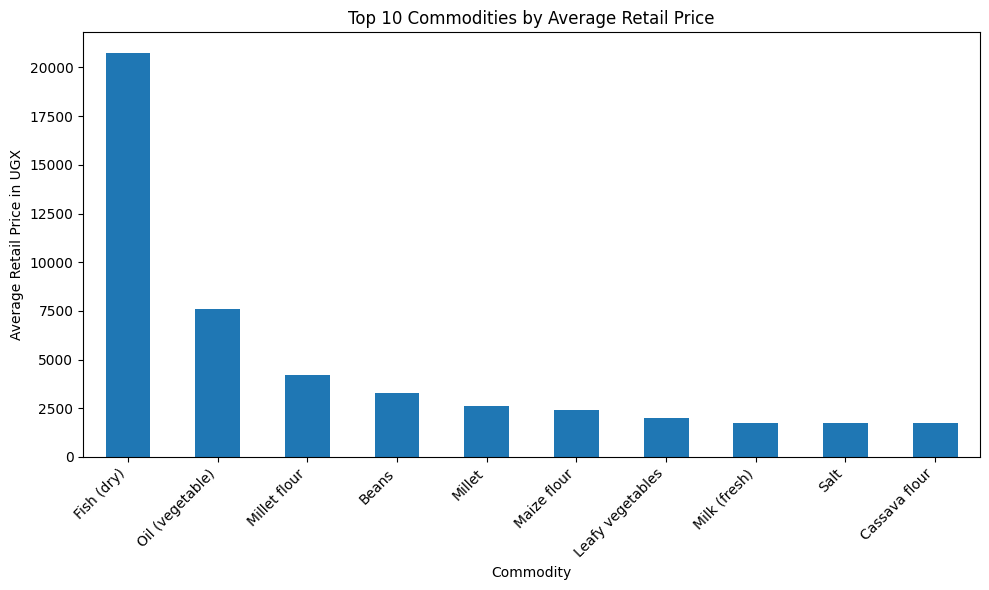

In [26]:
#visualize
plt.figure(figsize=(10, 6))
avg_price_commodity.plot(kind="bar")
plt.title("Top 10 Commodities by Average Retail Price")
plt.xlabel("Commodity")
plt.ylabel("Average Retail Price in UGX")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig("figures/top_10_commodities_by_average_retail_price.png", dpi=300)
plt.show()

This chart shows the commodities with the highest average retail prices. Differences in average prices are expected because commodities are measured in different units and have different market values.

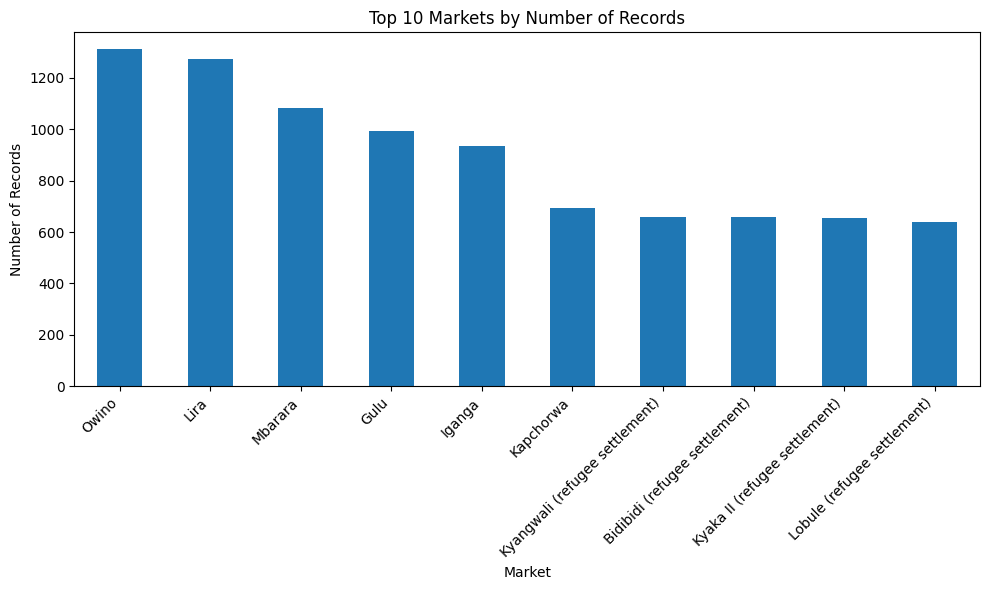

In [27]:
# check markets with the most records
top_markets = ml_df["market"].value_counts().head(10)

plt.figure(figsize=(10, 6))
top_markets.plot(kind="bar")
plt.title("Top 10 Markets by Number of Records")
plt.xlabel("Market")
plt.ylabel("Number of Records")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig("figures/top_10_commodities.png", dpi=300)
plt.show()

The chart shows which markets have the most price records. Markets with more records provide stronger historical information for the prediction model.

In [28]:
#save the generated figures
import os

os.makedirs("figures", exist_ok=True)

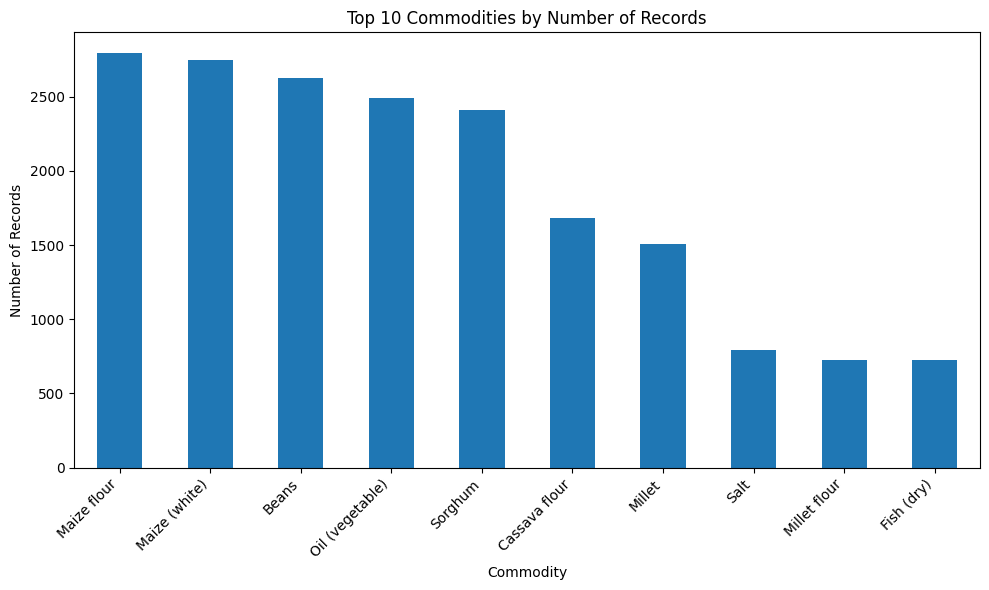

In [31]:
plt.figure(figsize=(10, 6))
ml_df["commodity"].value_counts().head(10).plot(kind="bar")
plt.title("Top 10 Commodities by Number of Records")
plt.xlabel("Commodity")
plt.ylabel("Number of Records")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig("figures/top_10_commodities.png", dpi=300)
plt.show()

#Summary: Data Exploration and Visualization

In this step, exploratory data analysis was performed on the cleaned WFP Uganda retail food price dataset.

The analysis included:
- Checking the structure of the cleaned dataset
- Examining the distribution of retail food prices
- Identifying the most frequently recorded commodities
- Comparing record counts across food categories
- Comparing average prices across food categories
- Analyzing food price trends over time
- Comparing price trends by category
- Examining the relationship between current price and next month price
- Checking correlations among numeric price features

The visualizations showed that food prices vary by commodity, category, market, and time. The relationship between current price, previous prices, moving averages, and next month price supports the use of regression modelling for this project.